In [133]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [134]:
data = pd.read_csv('housePrice.csv')

In [135]:
data

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33
...,...,...,...,...,...,...,...,...
3474,86,2,True,True,True,Southern Janatabad,3.500000e+09,116666.67
3475,83,2,True,True,True,Niavaran,6.800000e+09,226666.67
3476,75,2,False,False,False,Parand,3.650000e+08,12166.67
3477,105,2,True,True,True,Dorous,5.600000e+09,186666.67


Data Cleaning

missing data

In [137]:
data['Area'] = pd.to_numeric(data['Area'], errors='coerce')
data['Room'] = pd.to_numeric(data['Room'], errors='coerce')
mask = {
    "True": 1,
    "False": 0,
    True: 1,
    False: 0
}
data['Parking'] = data['Parking'].map(mask)
data['Warehouse'] = data['Warehouse'].map(mask, na_action=None)
data['Elevator'] = data['Elevator'].map(mask, na_action=None)
data = data.dropna()
data.describe()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD)
count,3450.000000,3450.000000,3450.000000,3450.000000,3450.000000,3.450000e+03,3.450000e+03
mean,106.917391,2.081159,0.847536,0.915072,0.787536,5.375563e+09,1.791854e+05
std,69.550976,0.760216,0.359522,0.278814,0.409111,8.125918e+09,2.708639e+05
min,30.000000,0.000000,0.000000,0.000000,0.000000,3.600000e+06,1.200000e+02
25%,69.000000,2.000000,1.000000,1.000000,1.000000,1.419250e+09,4.730833e+04
50%,90.000000,2.000000,1.000000,1.000000,1.000000,2.900000e+09,9.666667e+04
75%,120.000000,2.000000,1.000000,1.000000,1.000000,6.000000e+09,2.000000e+05
max,929.000000,5.000000,1.000000,1.000000,1.000000,9.240000e+10,3.080000e+06


In [147]:
max_area = data['Area'].quantile(0.99)  
data = data[data['Area'] <= max_area]
for index, row in data.iterrows():
    if row['Area'] > max_area:
        data.drop(index, inplace=True)  

data.reset_index(drop=True, inplace=True)

print("Max Area (99th percentile):", max_area) 
print(data)  

Max Area (99th percentile): 300.0
       Area  Room  Parking  Warehouse  Elevator             Address  \
0      63.0     1        1          1         1             Shahran   
1      60.0     1        1          1         1             Shahran   
2      79.0     2        1          1         1              Pardis   
3      95.0     2        1          1         1       Shahrake Qods   
4     123.0     2        1          1         1      Shahrake Gharb   
...     ...   ...      ...        ...       ...                 ...   
3384   86.0     2        1          1         1  Southern Janatabad   
3385   83.0     2        1          1         1            Niavaran   
3386   75.0     2        0          0         0              Parand   
3387  105.0     2        1          1         1              Dorous   
3388   82.0     2        0          1         1              Parand   

             Price  Price(USD)  
0     1.850000e+09    61666.67  
1     1.850000e+09    61666.67  
2     5.500000

In [148]:
missing_values = data.isna().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address       0
Price         0
Price(USD)    0
dtype: int64


[]

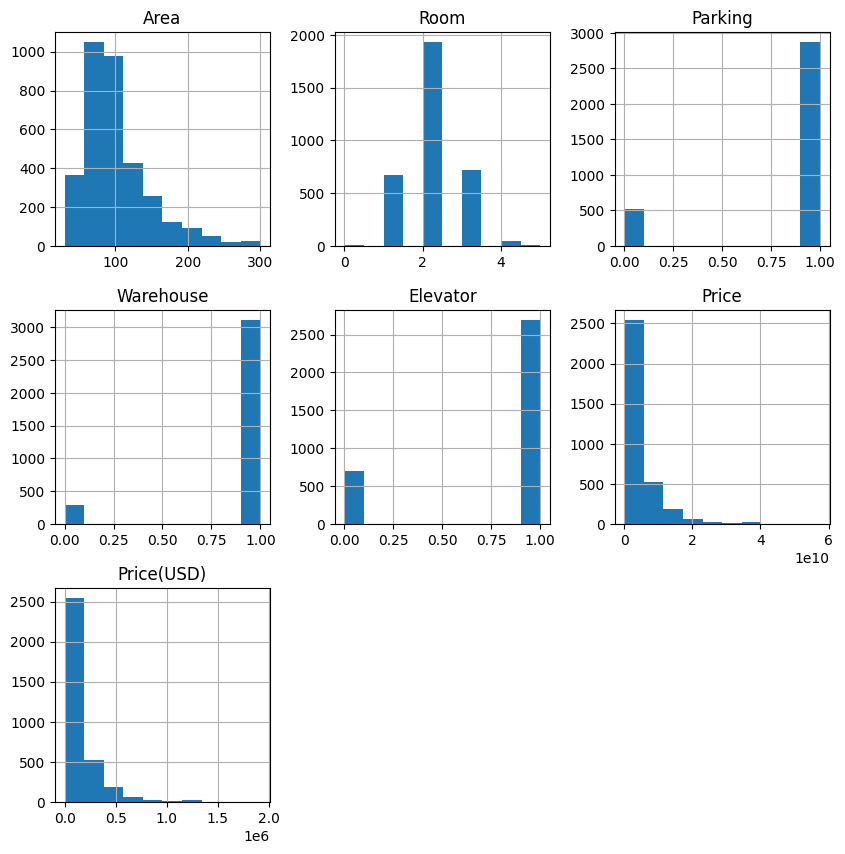

In [149]:
data.hist(figsize=(10, 10))
plt.plot()

Regression

In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()
from sklearn import linear_model

In [151]:
X = data[['Area', 'Room', 'Parking', 'Warehouse', 'Elevator']]
Y = data[['Price(USD)']]
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42) 
X_train = scaler.fit_transform(X)
X_test = scaler.fit_transform(X)
y_train = scaler.fit_transform(Y)
y_test = scaler.fit_transform(Y)

In [152]:
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)
print("coef:", reg.coef_)
print("intercept:", reg.intercept_)

coef: [[ 0.93985153 -0.19257244  0.01732889  0.02235508  0.00925204]]
intercept: [4.32974985e-18]


In [153]:
from sklearn import linear_model

reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

LinearRegression()

In [154]:
from sklearn.metrics import r2_score

y_test_ = reg.predict(X_test)
score = r2_score(y_test, y_test_)
print("score:", score)

score: 0.6499323542185499


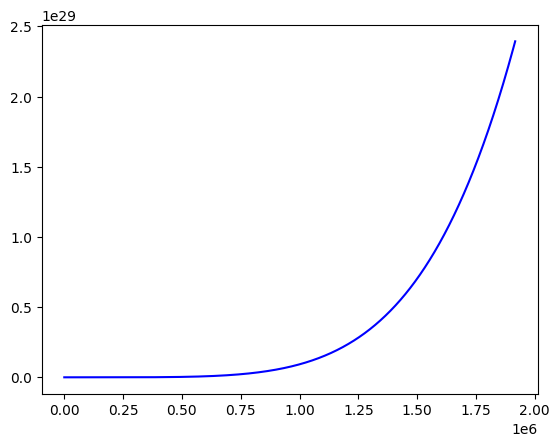

In [155]:
x = np.arange(min(data['Price(USD)']), max(data['Price(USD)']), 0.1)
y = reg.intercept_[0] + reg.coef_[0][0] * x + reg.coef_[0][1] * pow(x, 2) + reg.coef_[0][2] * pow(x, 3) + reg.coef_[0][3] * pow(x, 4) + reg.coef_[0][4] * pow(x, 5)
plt.plot(x, y, color='blue')
plt.show()